# Ch10 언어 모델을 위한 신경망 
# Ch10-1 어텐션 메커니즘과 트랜스포머



## 1. 순환 신경망을 사용한 인코더-디코더 네트워크

## 2. 어텐션 메커니즘 Attention mechanism
순환 신경망 기단 인코더-디코더 모델의 성능을 크게 향상시킨 기술.        
인코더의 모든 타임스텝에서 계산된 은닉 상태를 활용할 수 있음        


## 3. 트랜스포머
 기존의 인코더-디코더 구조를 유지하면서도 순환 신경망을 완전히 제거     
 따라서 입력 텍스트를한토•큰씩 처리할 필요 없이 한 번에 모두 처리할수 있음          
 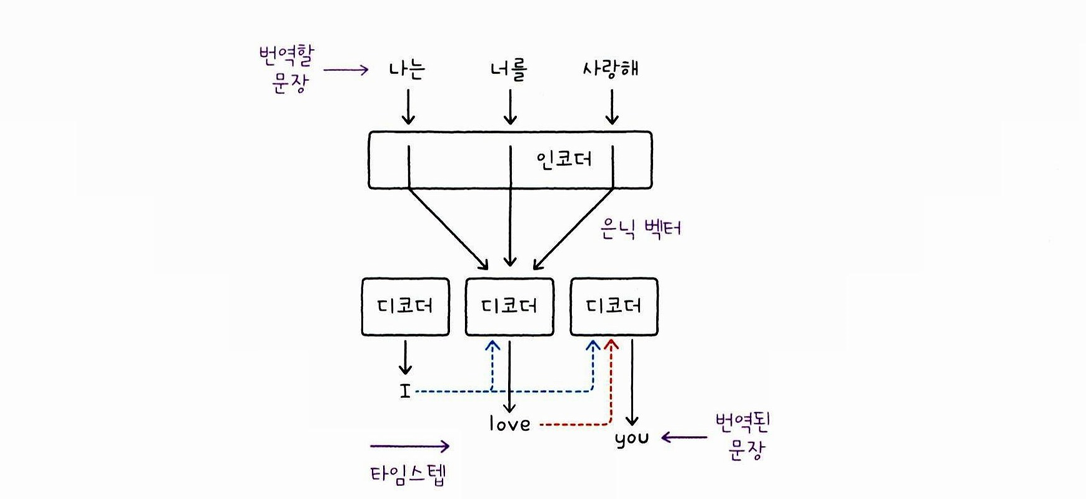


### 트랜스포머의 작동 방식

**- 인코더** : 입력된 텍스트를 한 번에 모두 처리.       
      - 기존의 순환 신경망과 달리, 타입 스텝 개념이 필요하지 않음.        
      - 입력 텍스트 길이에 제한이 있는 단점이 있으나, 한 번에 모두 처리할 수 있으므르 ㅗ 모델의 처리 속도가 크게 향상됨.      
      - 그러나 계속 발전하면서 더 긴 문장이나 문서 전체를 처리할 수도 있음        

**- 디코더** : 인코딩 결과가 전달되어, 이를 바탕으로 번역된 문장을 생성             
        - 기존 순환 신경망은 디코더가 인코더의 마지막 은닉 상태를 받아 번역을 수행      
        - 그러나, 트랜스포머는 은닉 상태가 아닌 **은닉 벡터_hidden vector** 또는 **단어 벡터_word vector**, **임베딩 벡터_embedding vector** 라는 표현을 사용    
        - 인코더 -> 은닉 벡터 -> 디코더 -> 출력할 토큰 생성          


## 4. 셀프 어텐션 메커니즘

트랜스포머에서는 인코더에 입력되는 토큰만으로 어텐션 가중치를 학습하게 만들었음. 이를 **셀프 어텐션_self-attention**이라고 함       

### 셀프 어텐션의 계산 과정

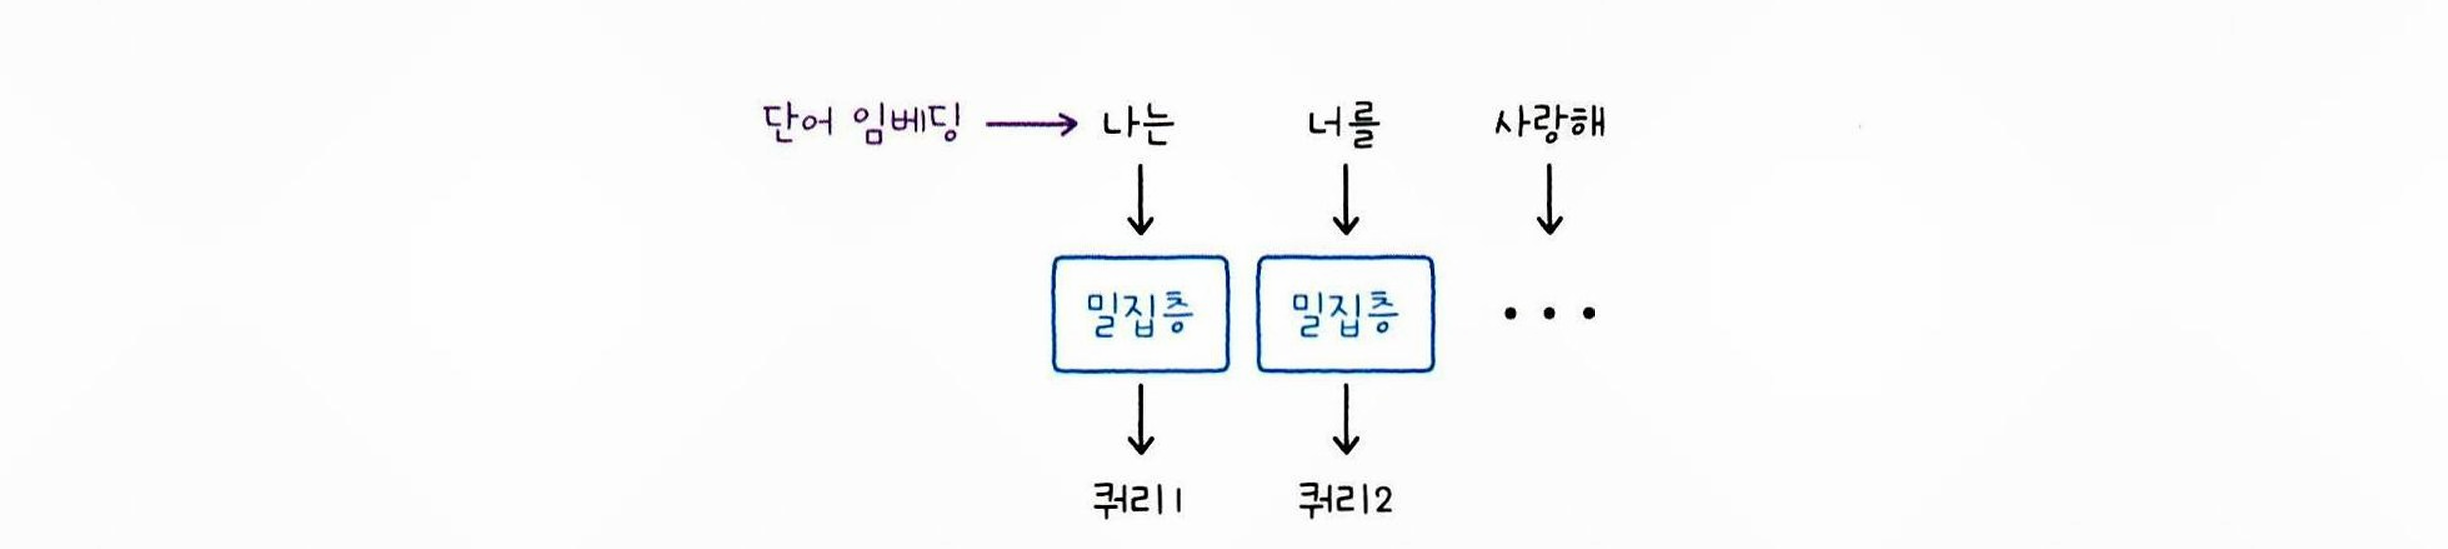
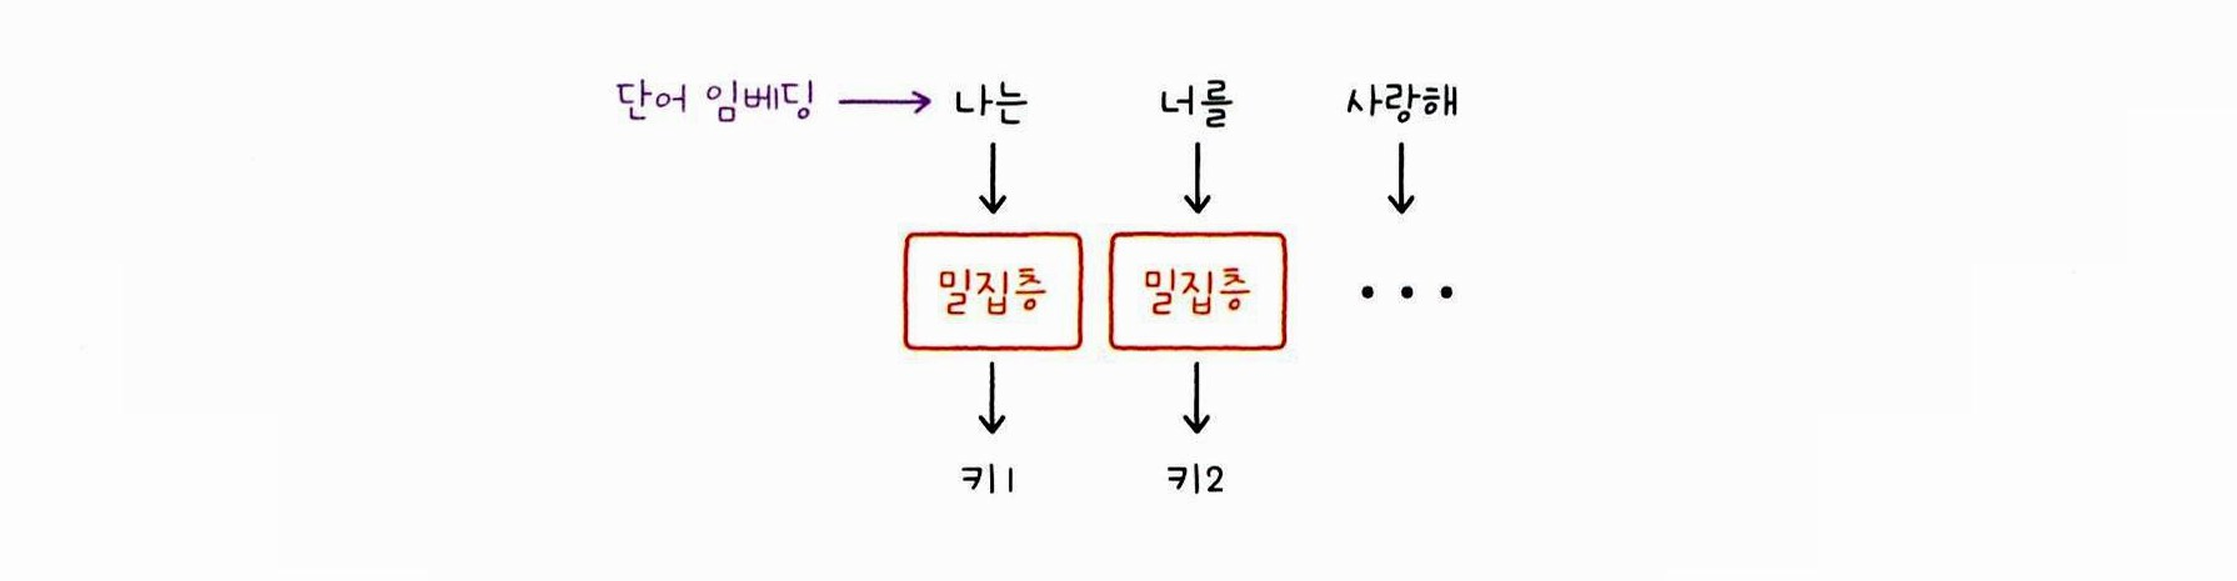
1. 입력 텍스트의 각 토큰을 밀집층에 한 번에 통과  => 밀집층을 통과한 벡터 = **쿼리 벡터**       
2. 같은 입력 텍스트를 두 번째 밀집층에 통과 => **키 벡터**

### 어텐션 점수 계산

쿼리 벡터와 키 벡터가 생성되면 두 벡터를 서로 곱함 = **어텐션 점수_attention score**        
- 입력 토큰이 3개라면, 쿼리 벡터도 3개, 키 벡터도 3개 생성되고 어텐션 점수는 총 9개         
- 이를 행렬로 표시한 것이 **어텐션 행렬_Attention matrix**
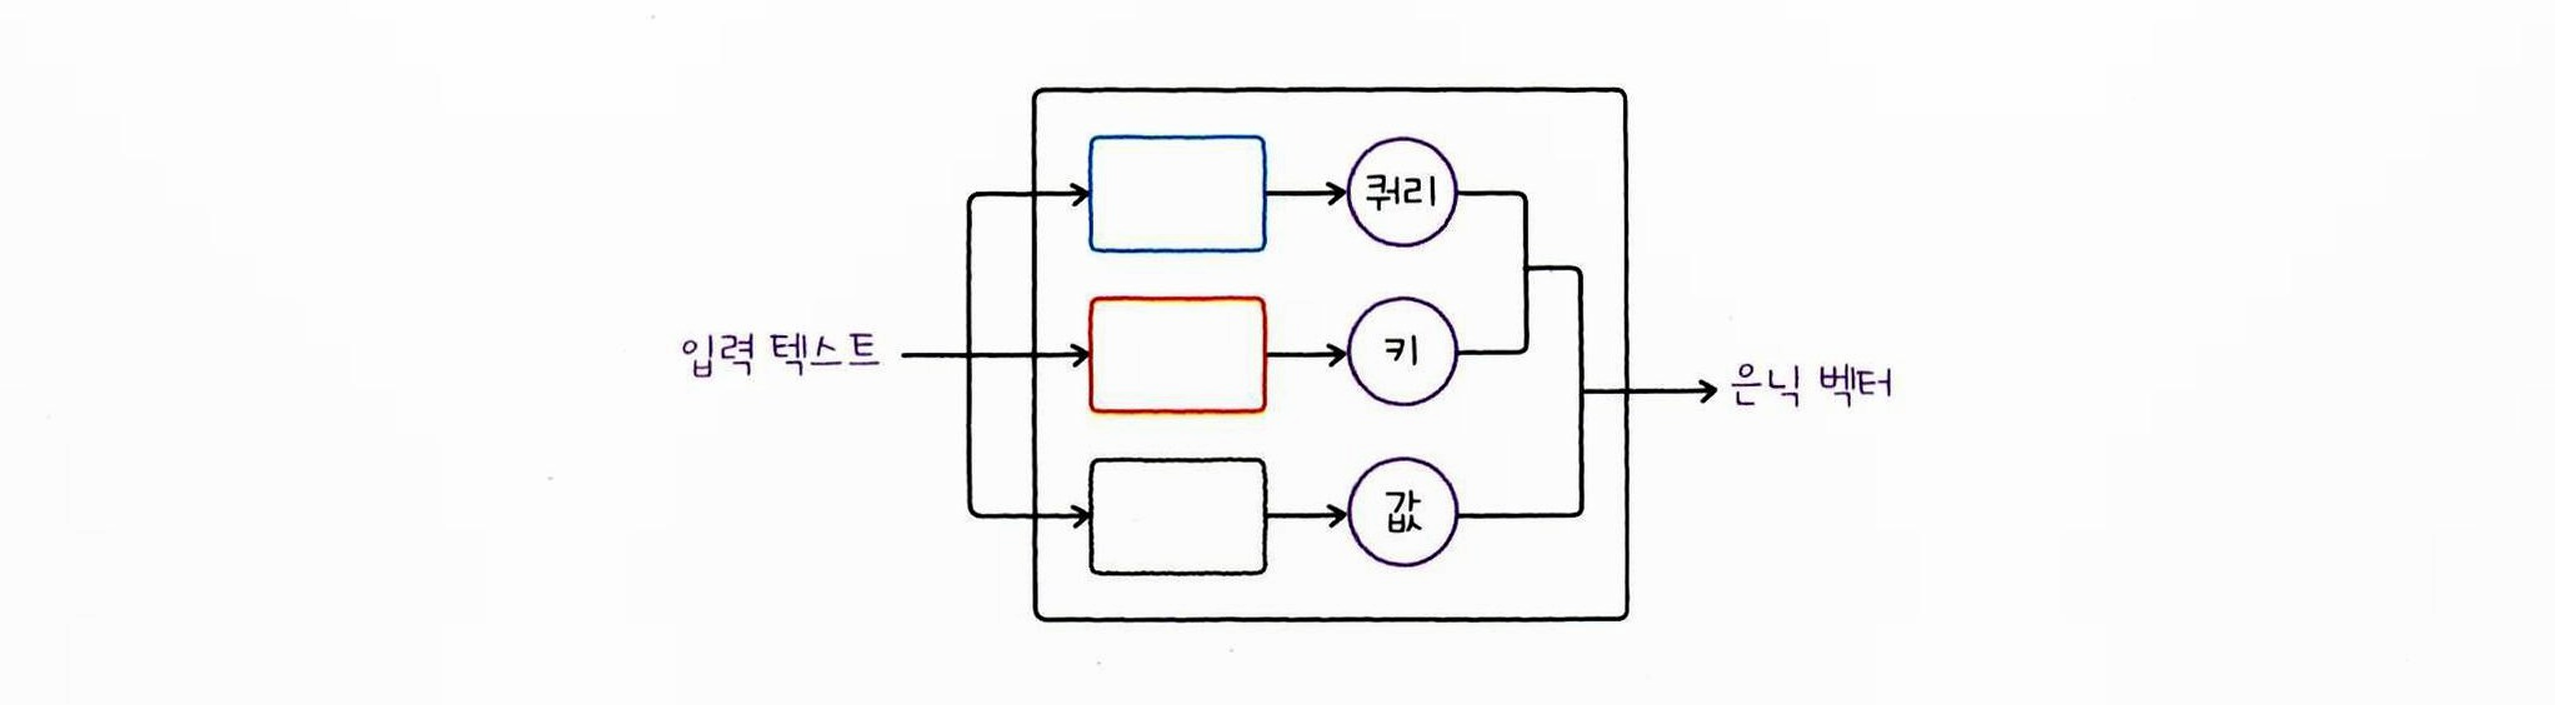

### 멀티 헤드 어텐션

셀프 어텐션 연산을 수행하는 하나의 단위를 **어텐션 헤드_attention head**라고 한다.    
트랜스포머는 여러개의 어탠션 헤드를 사용해서 **멀티 헤드 어텐션_multi-head attention**이라고 한다.      
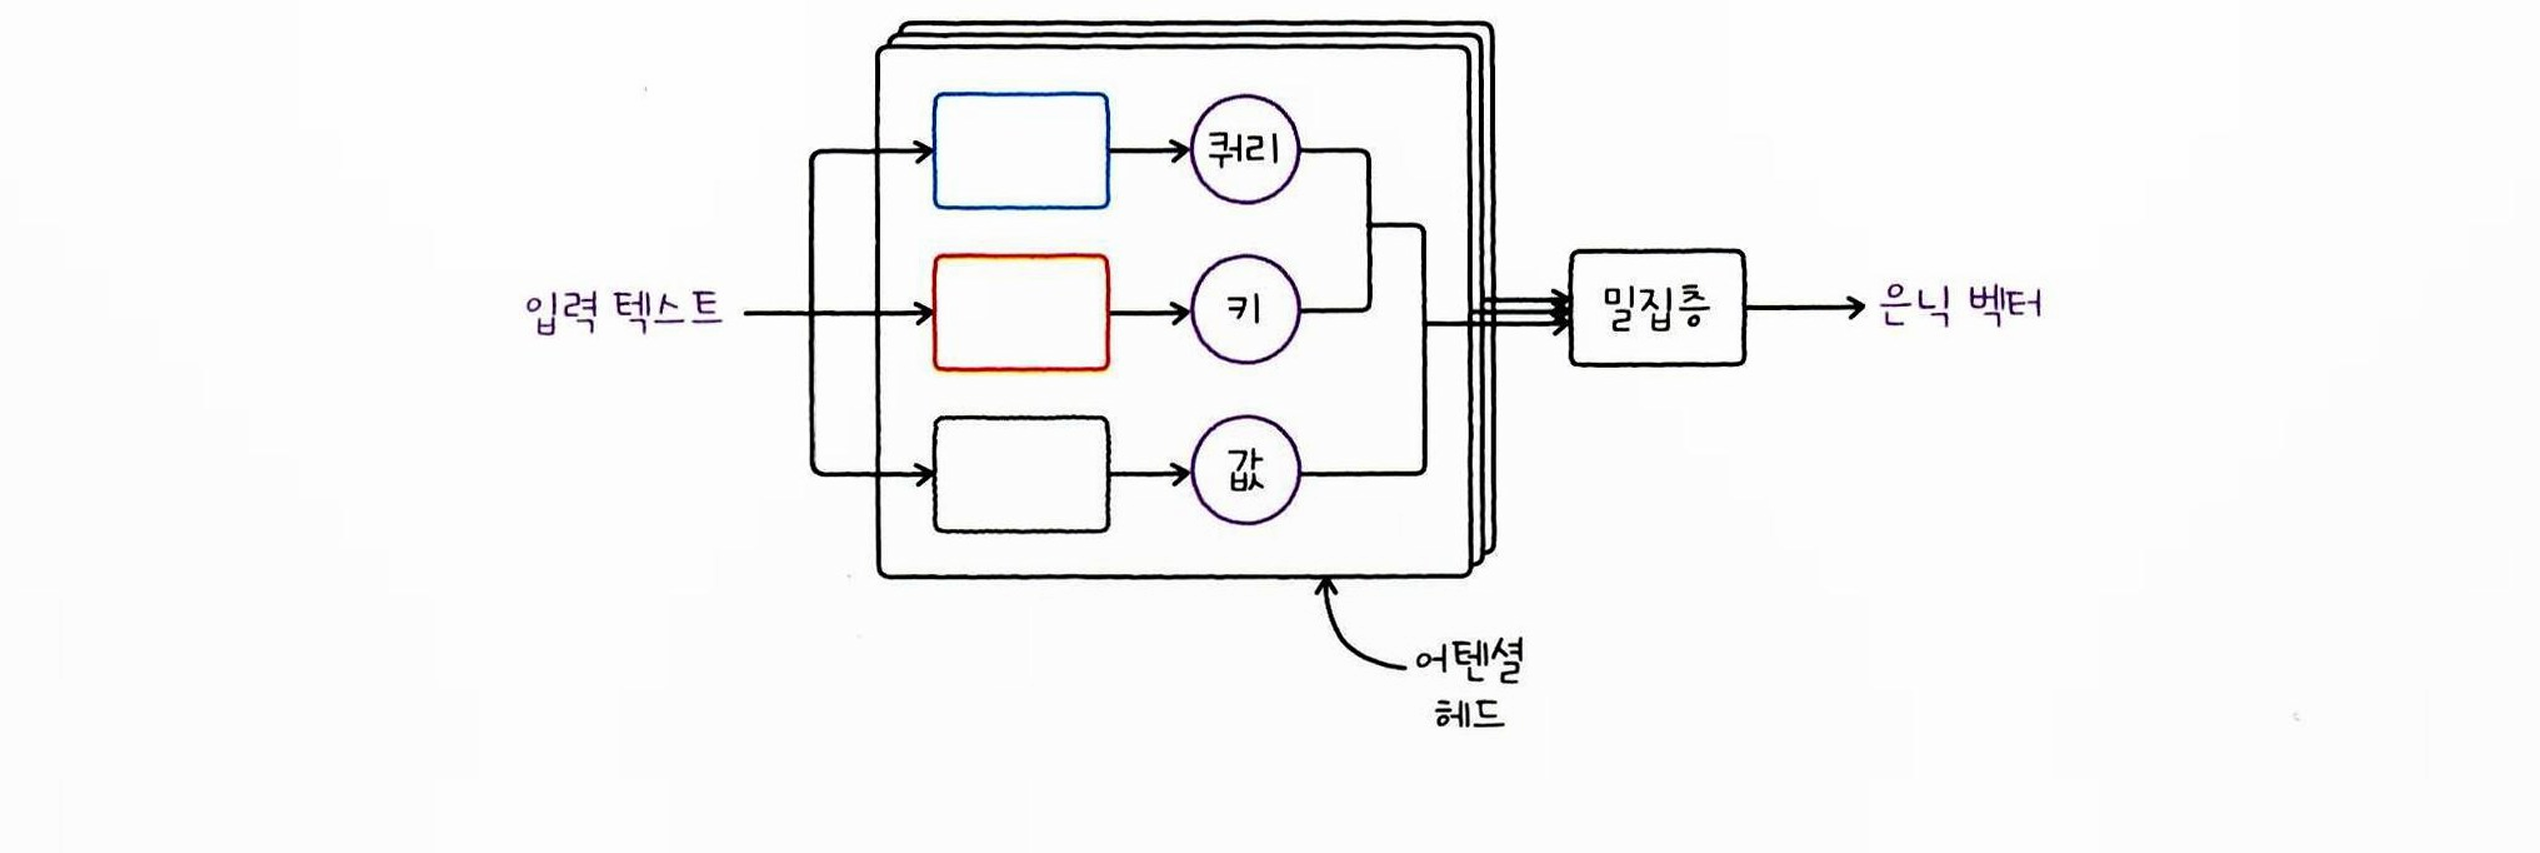

## 5. 층 정규화
딥러닝은 여러 개의 층을 거치면서 특성의 스케일이 변할 수 있으므로 단순한 입력 정규화만으로는 부족하고,      
**배치 정규화_batch normalization**을 해야한다.     

배치 정규화는 주로 합성곱 신경망에 주로 사용됨.  (층과 층 사이에 놓는다.)       

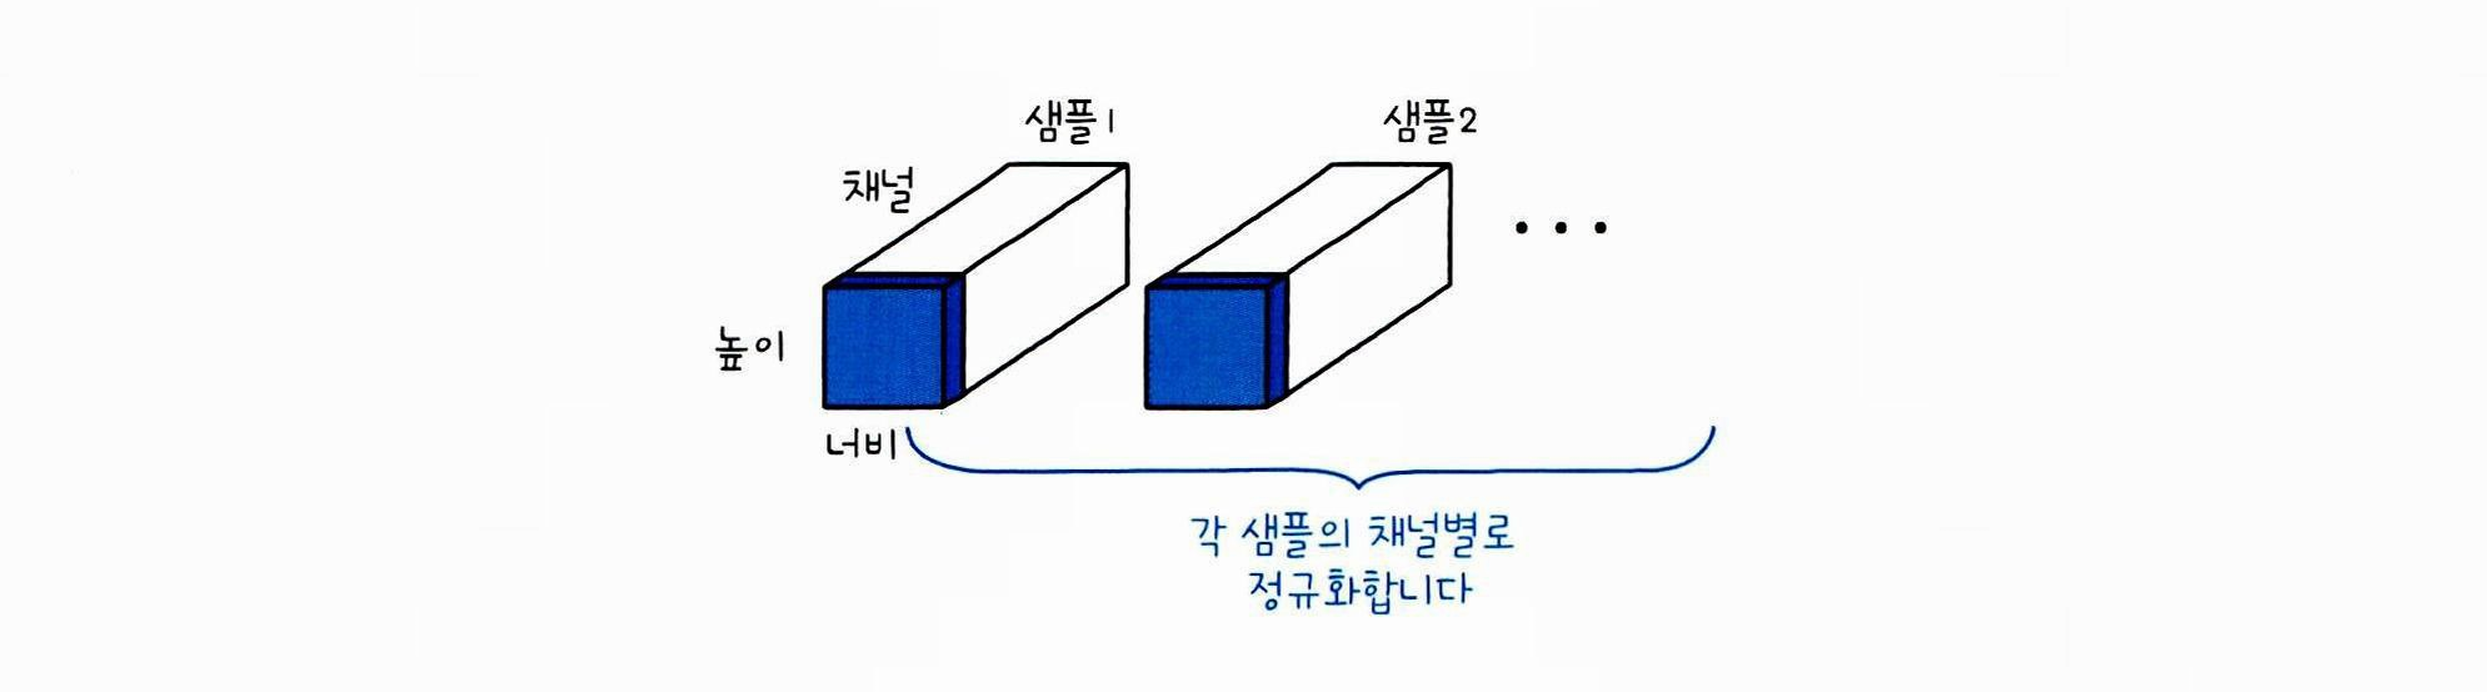

파란색이 정규화가 적용되는 단위.        
모든 샘플에서 특정 채널의 데이터를 모아 평균과 분산을 계산 -> 정규화를 적용    
> 배치 단위로 정규화를 수행하므로 배치 정규화라고 부른다.       

배치 정규화를 적용하면 훈련 속도가 빨라지고, 학습 과정이 안정화.        
그러나, 텍스트 데이터는 샘플마다 길이가 달라서, 적용하기 어렵기 때문에 고안된 것이 **층 정규화_lyaer normalization**        
층 정규화는 각 샘플의 토큰마다 개별적으로 정규화를 수행하는 방식        
샘플마다 길이가 달라도 독립적으로 정규화할 수 있어 샘플의 길이에 영향을 받지 않음       
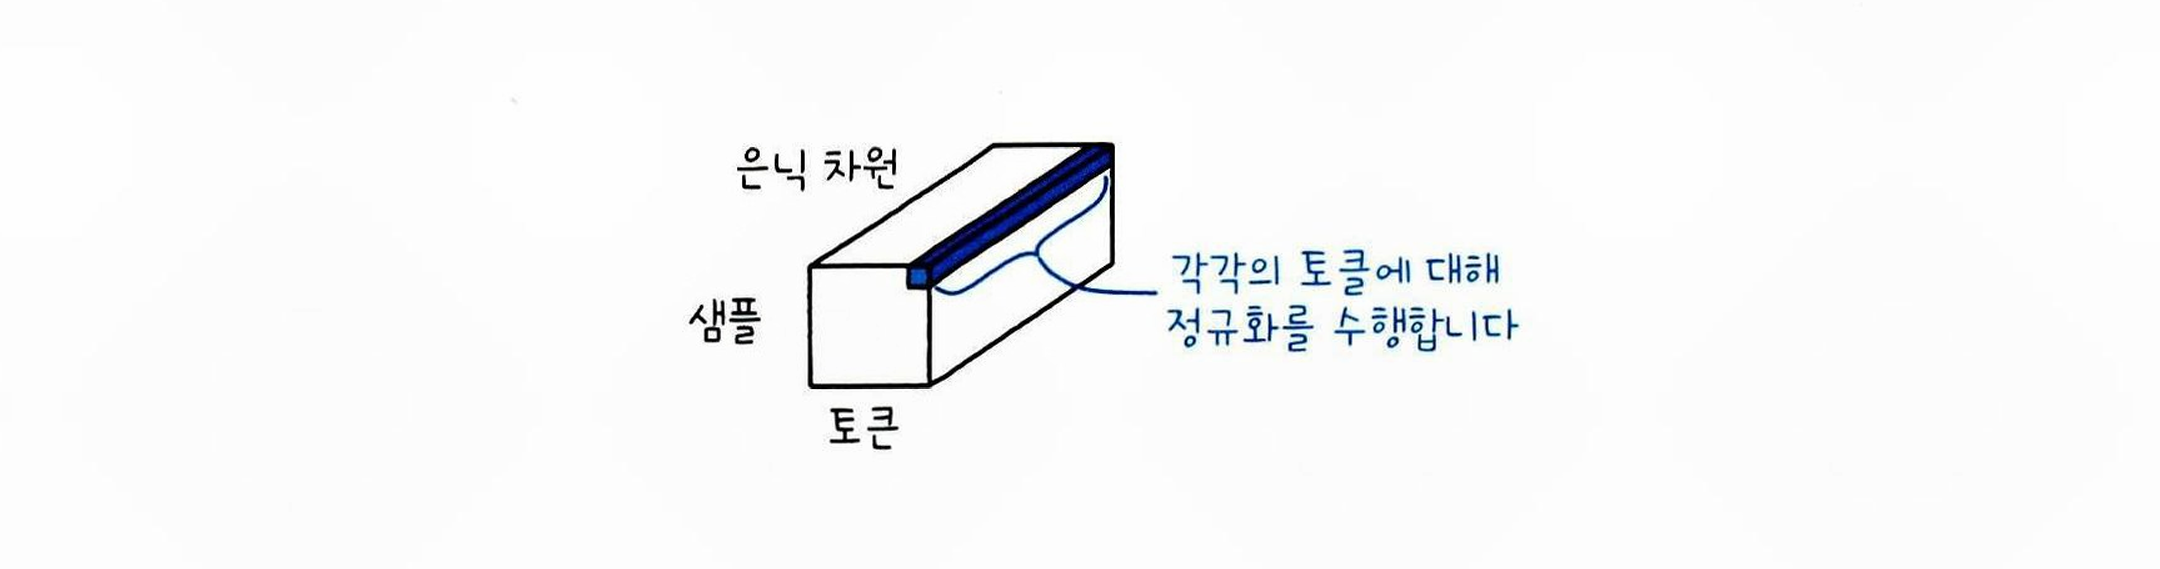
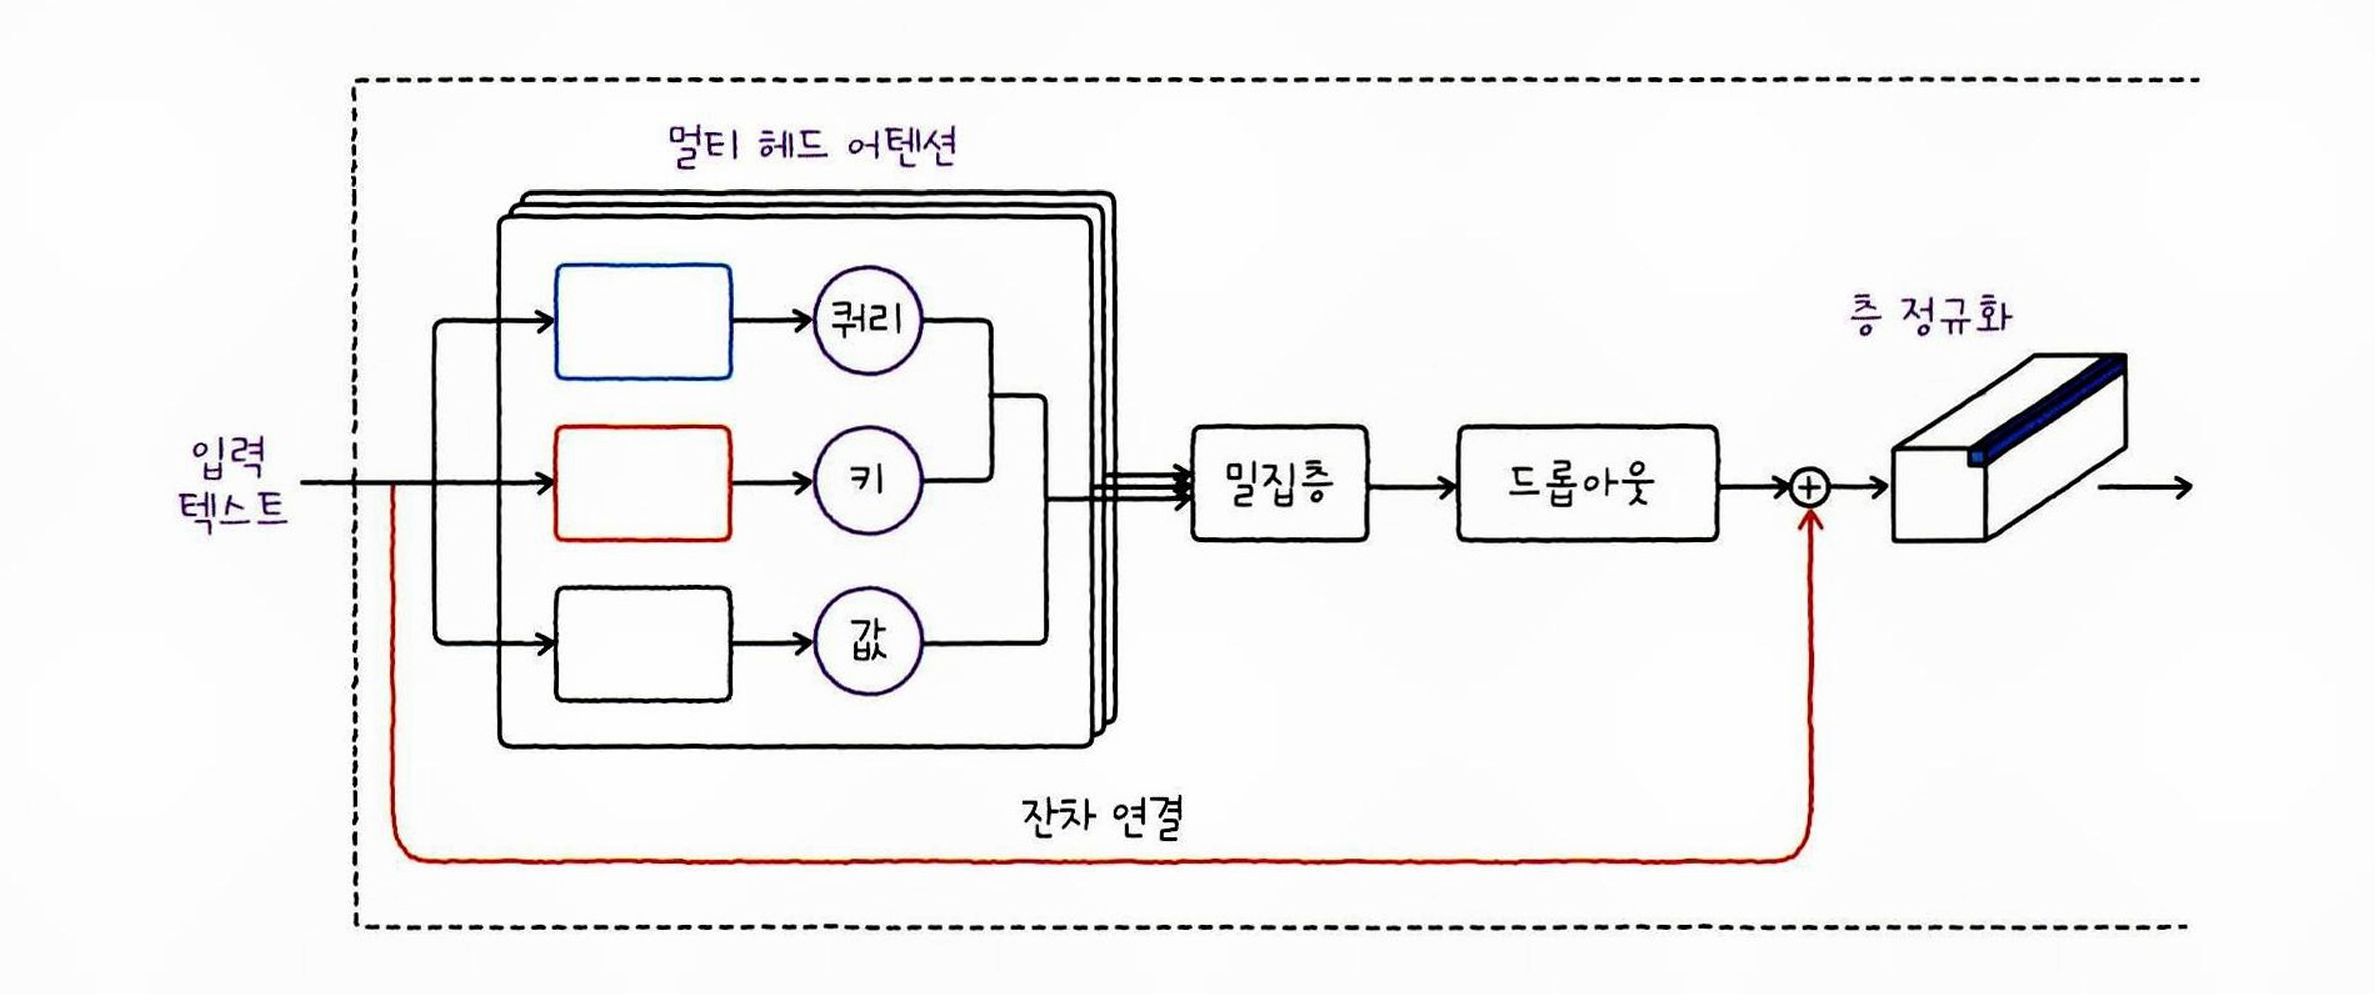

## 6. 피드포워드 네트워크와 인코더 블록
피드포워드 네트워크 = 트랜스포머의 인코더에서 멀티 헤드 어텐션과 층 정규화 다음에 나오는 밀집층     


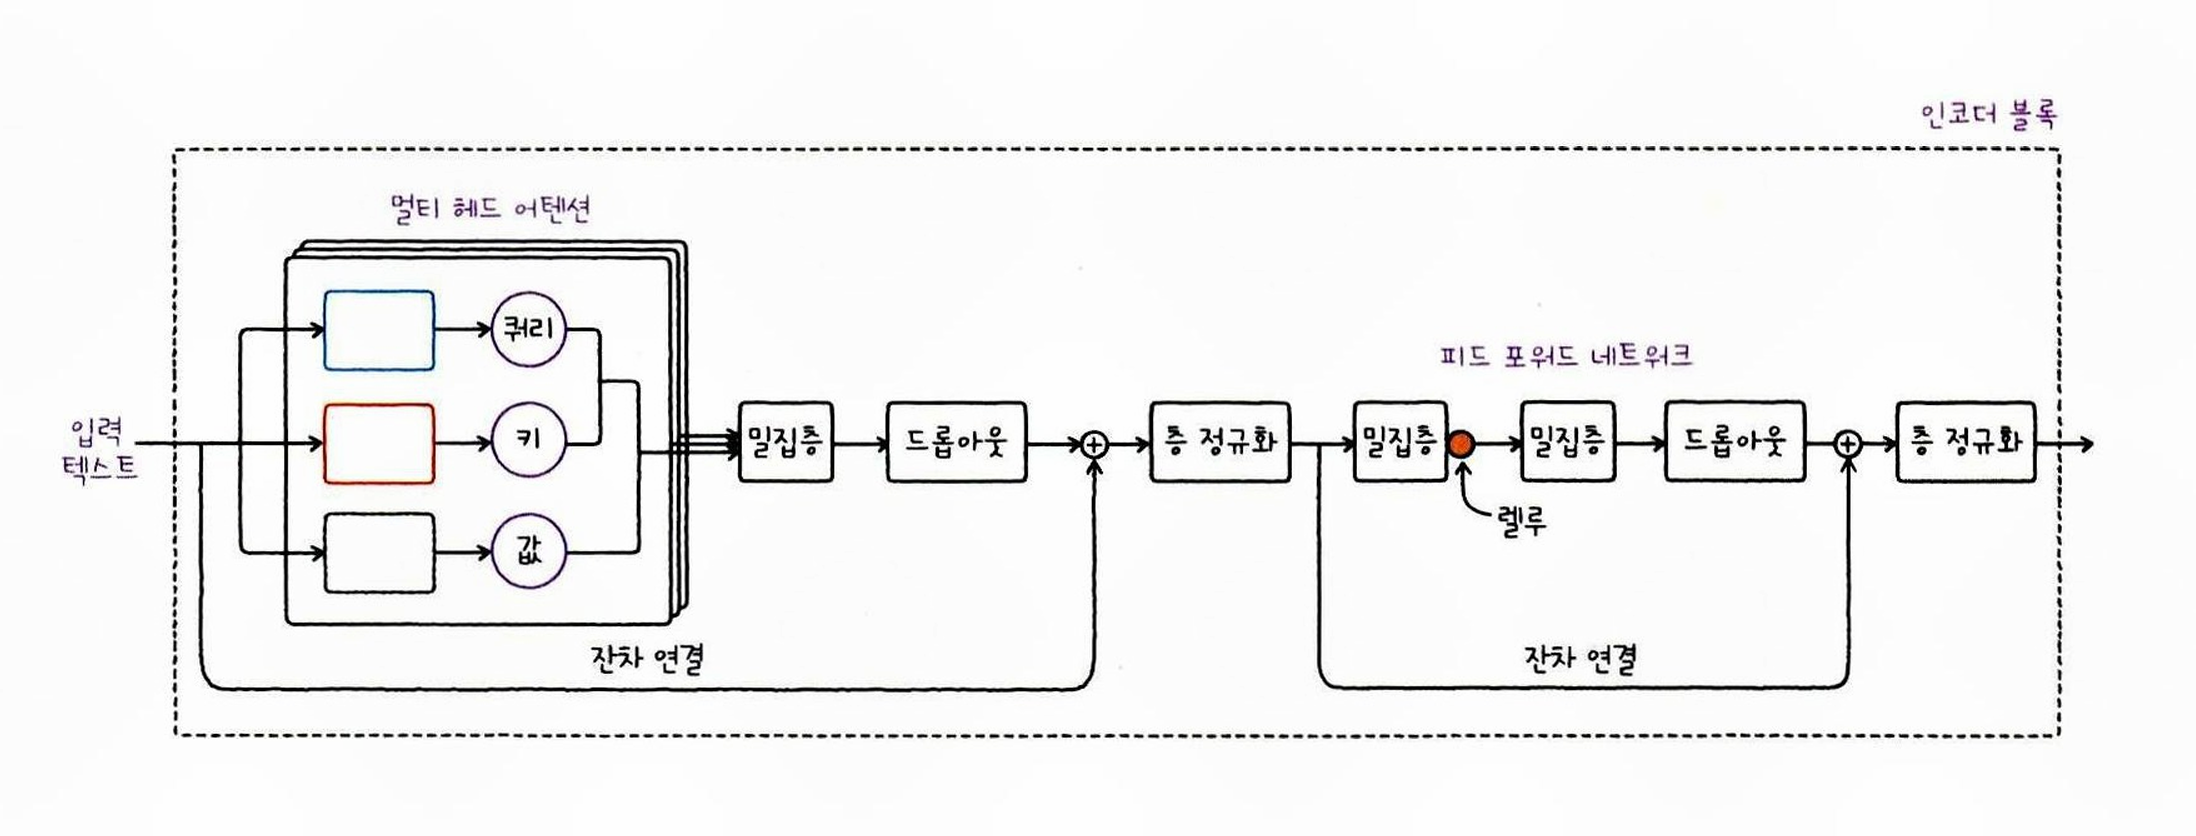

## 7. 토큰 임베딩과 위치 인코딩

### 토큰 임베딩
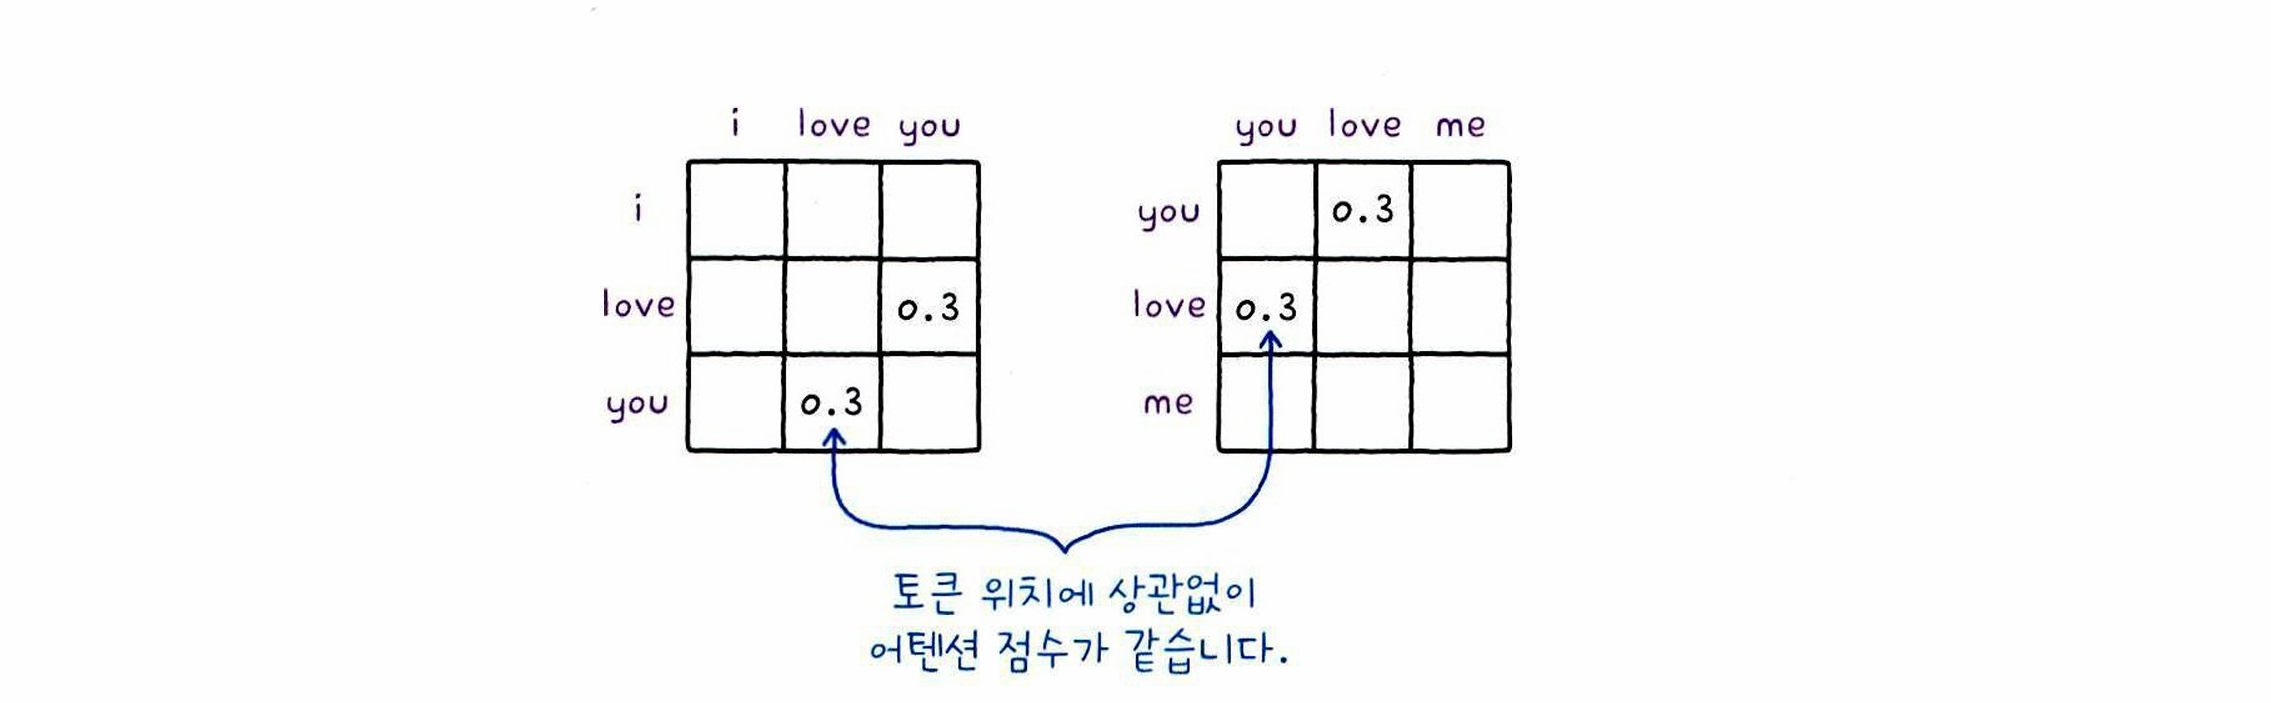

트랜스포머에서도 토큰을 고정된 크기의 실수 벡터로 변환하기 위해 임베딩을 사용하나, 토큰의 위치를 고려하지 않는 문제가 있음.     

### 위치 임베딩

따라서      
**위치 인코딩_positional encoding**을 사용하면 해결가능!        
**사인 함수** 와 **코사인 함수**를 사용해 토큰의 위치에 따라 변하는 벡터를 생성하고, 이를 임베딩에 더하는 방식      

만약, 임베딩 벡터의 차원이 5이고 모델에 입력되는 문장의 10번째 토큰이 [0.1, 0.2, 0.6, 0.3, 0.5] 로 표현된다면,

각 원소 인덱스를 임베딩 벡터 전체의 길이로 나누기 -> 값을 10,000의 거듭제곱한 값의 역수로 변환 -> 해당 토큰의 순서인 10을 곱하기 
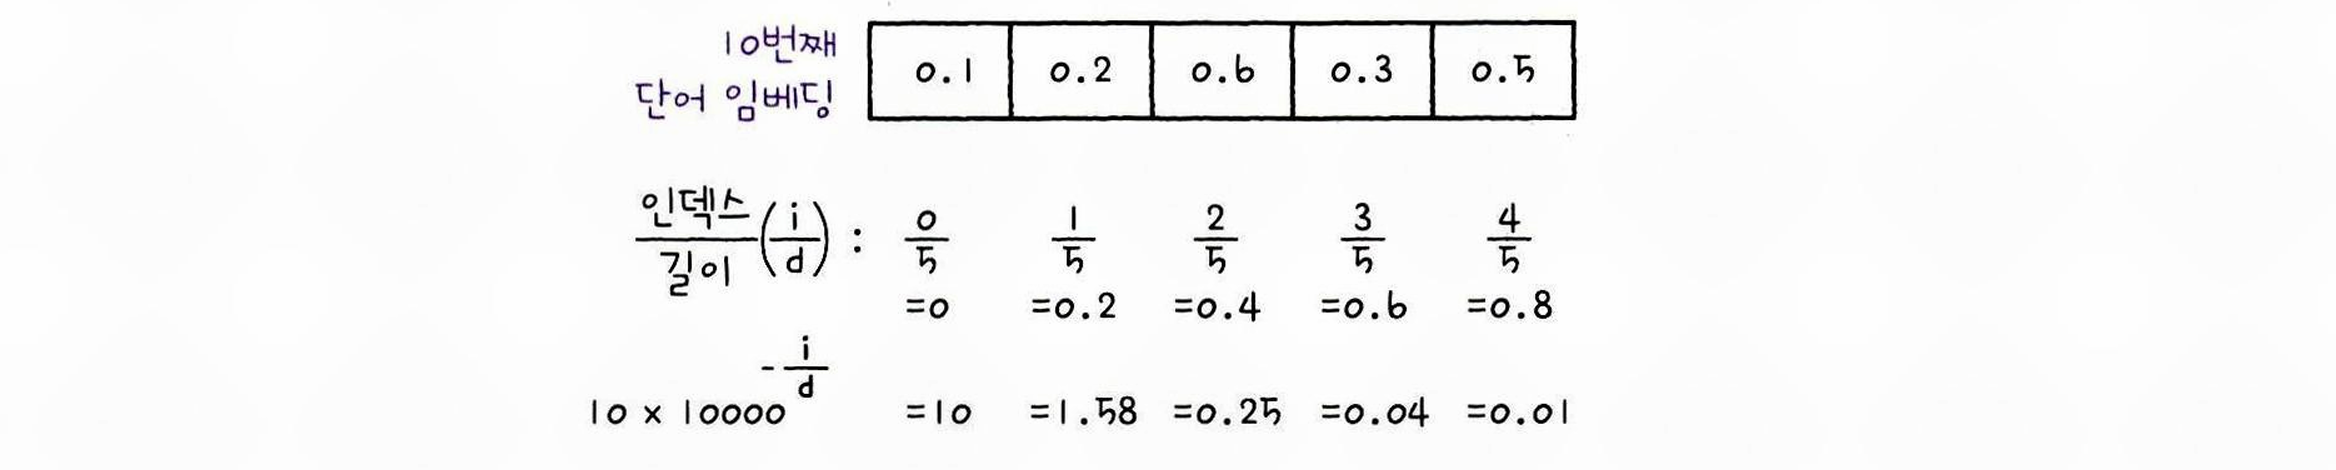
그 다음 짝수 번째 원소의 경우 **사인 함수** 적용 , 홀수 번째 원소의 경우 **코사인 함수** 적용
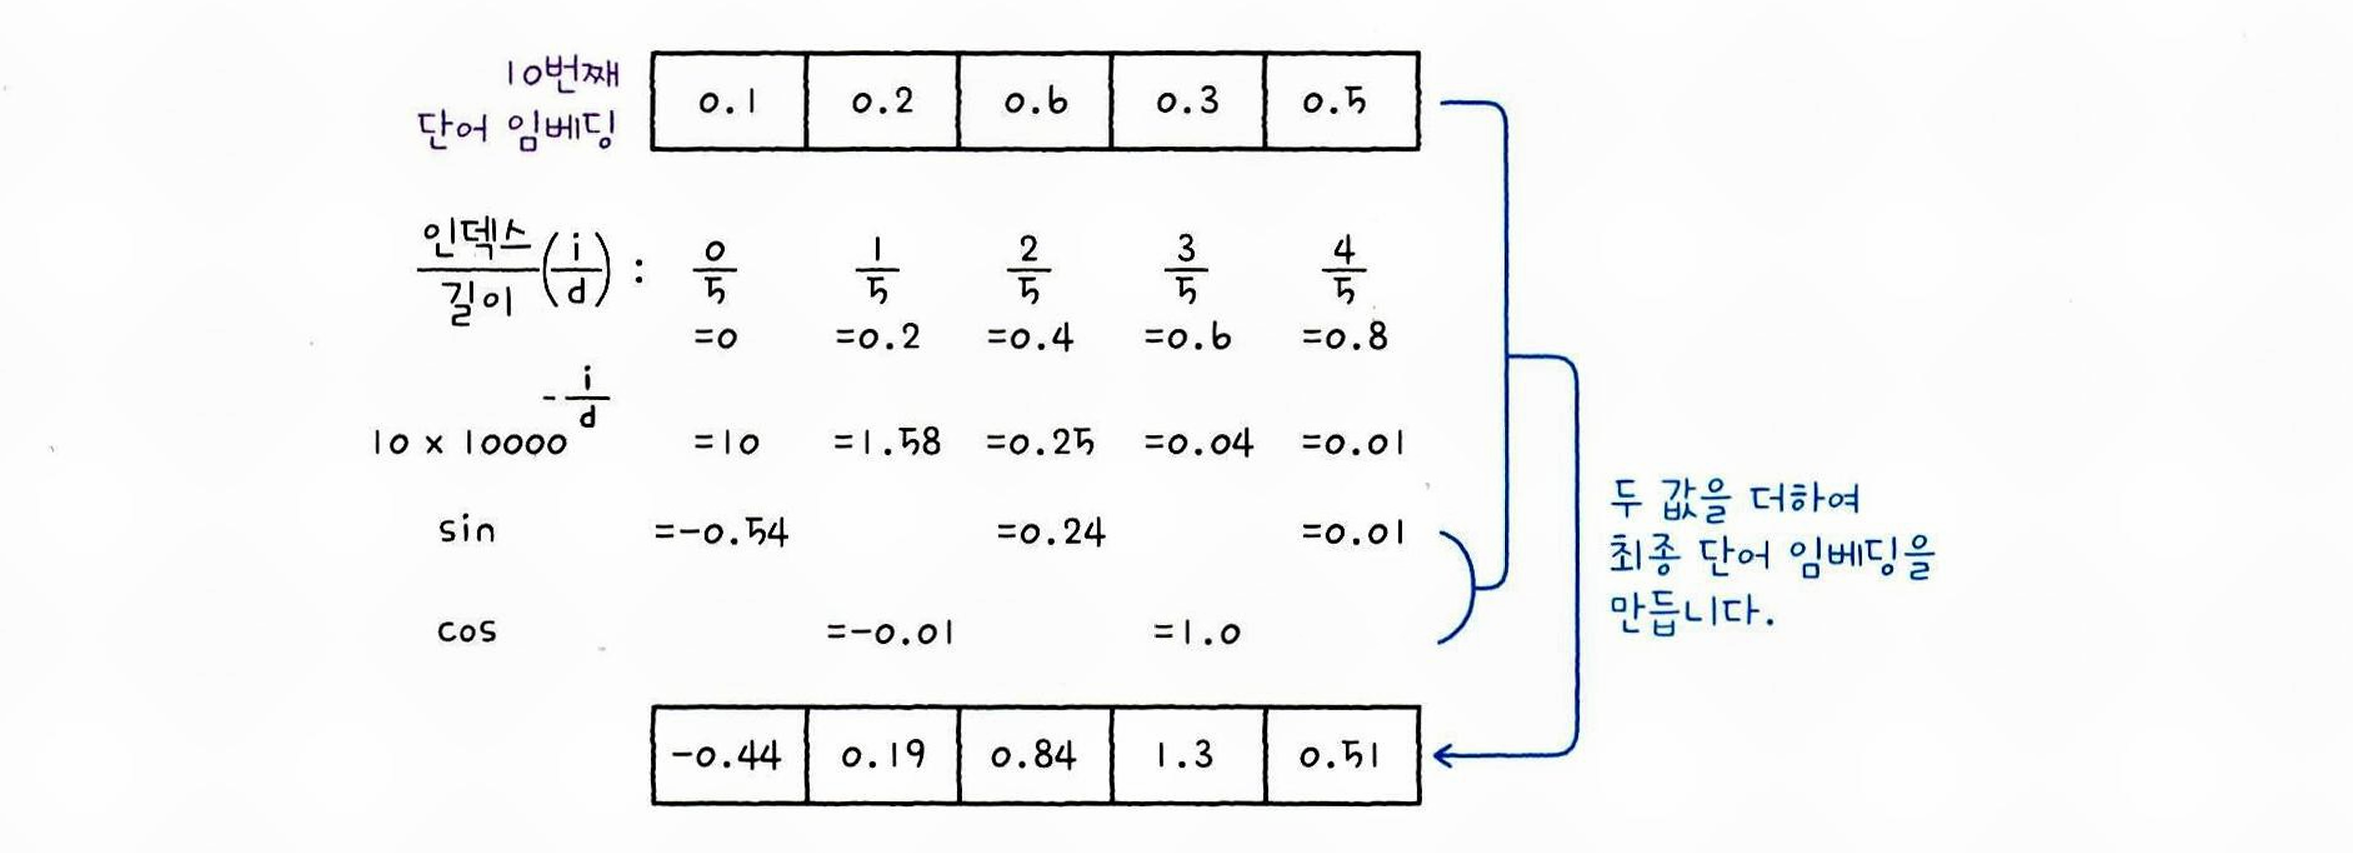


==> 결국 원본 단어 임베딩의 값은 문장에서의 위치에 따라 조금씩 달라짐 
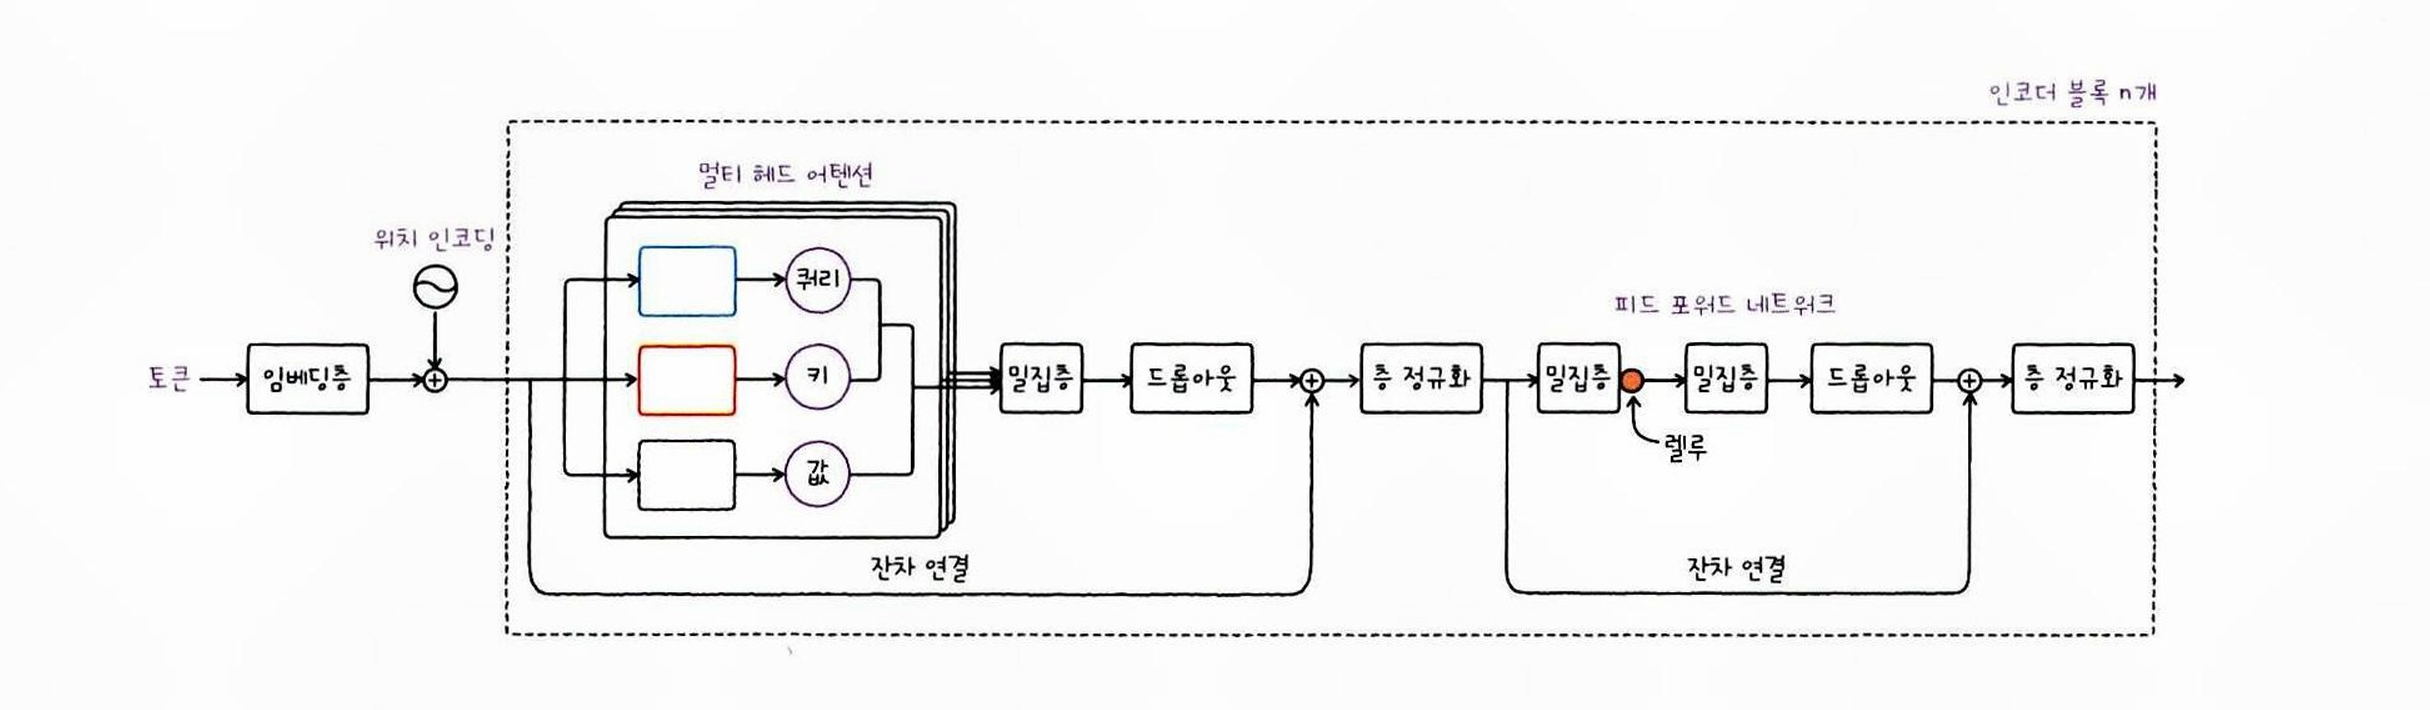

## 8. 디코더 블록

디코더 블록의 멀티 헤드 어텐션은 **크로스 어텐션_cross attention**이라고 부름       
- 인코더가 출력한 임베딩 벡터를 입력으로 받음   
- 디코더 블록에서는 크루스 어텐션 층이 인코더의 멀티 헤드 어텐션 층과 피드포워드 네트워크 사이에 배치          
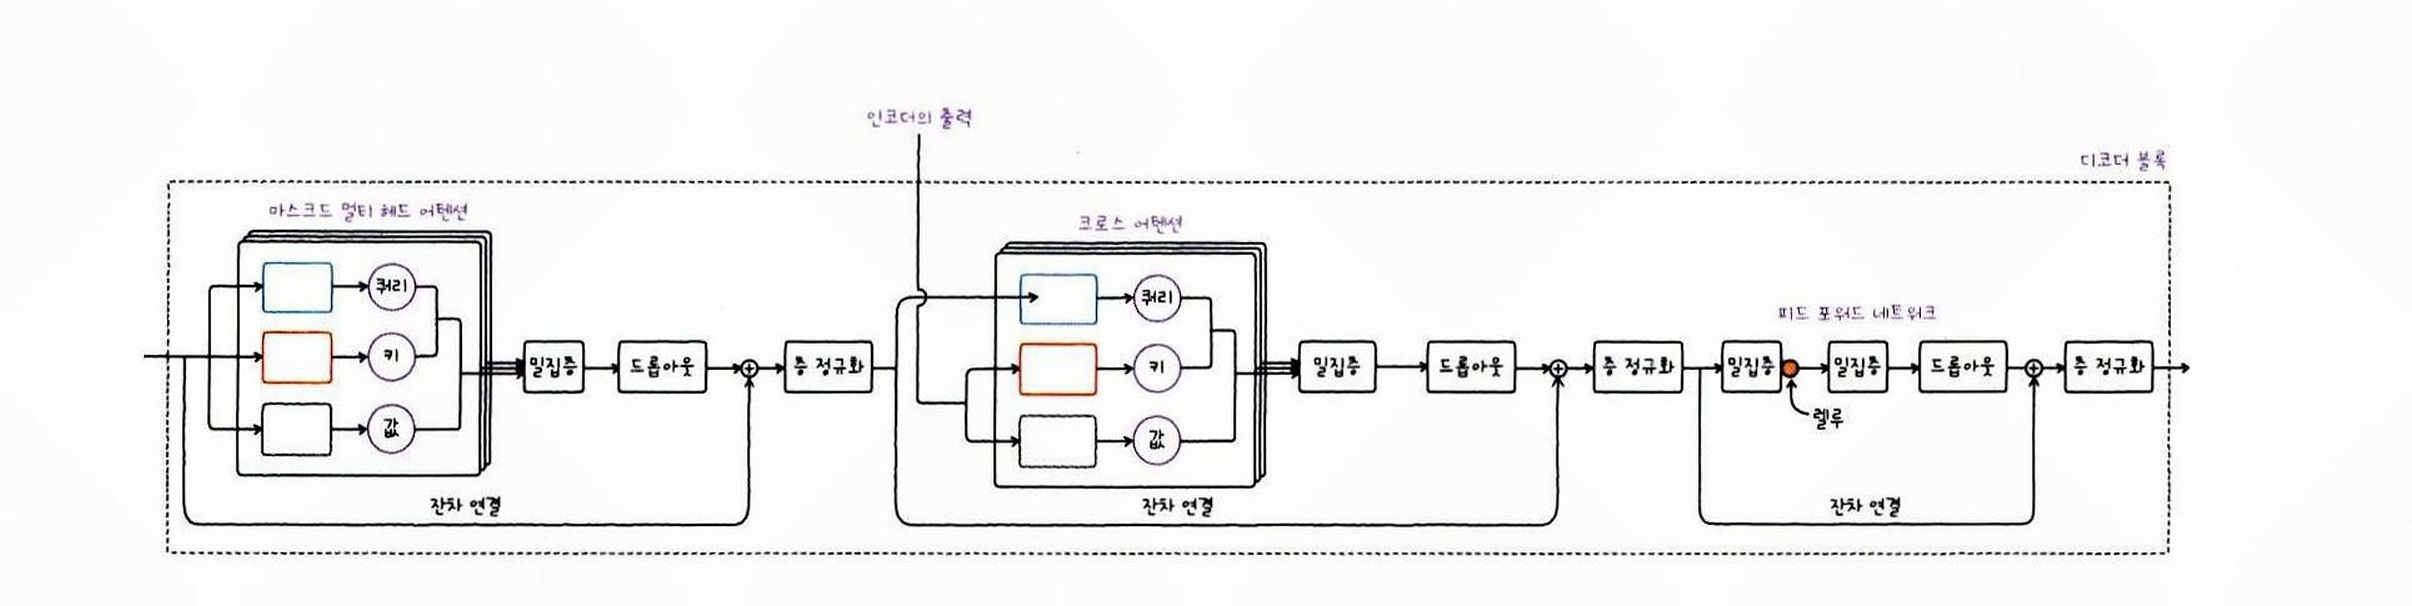
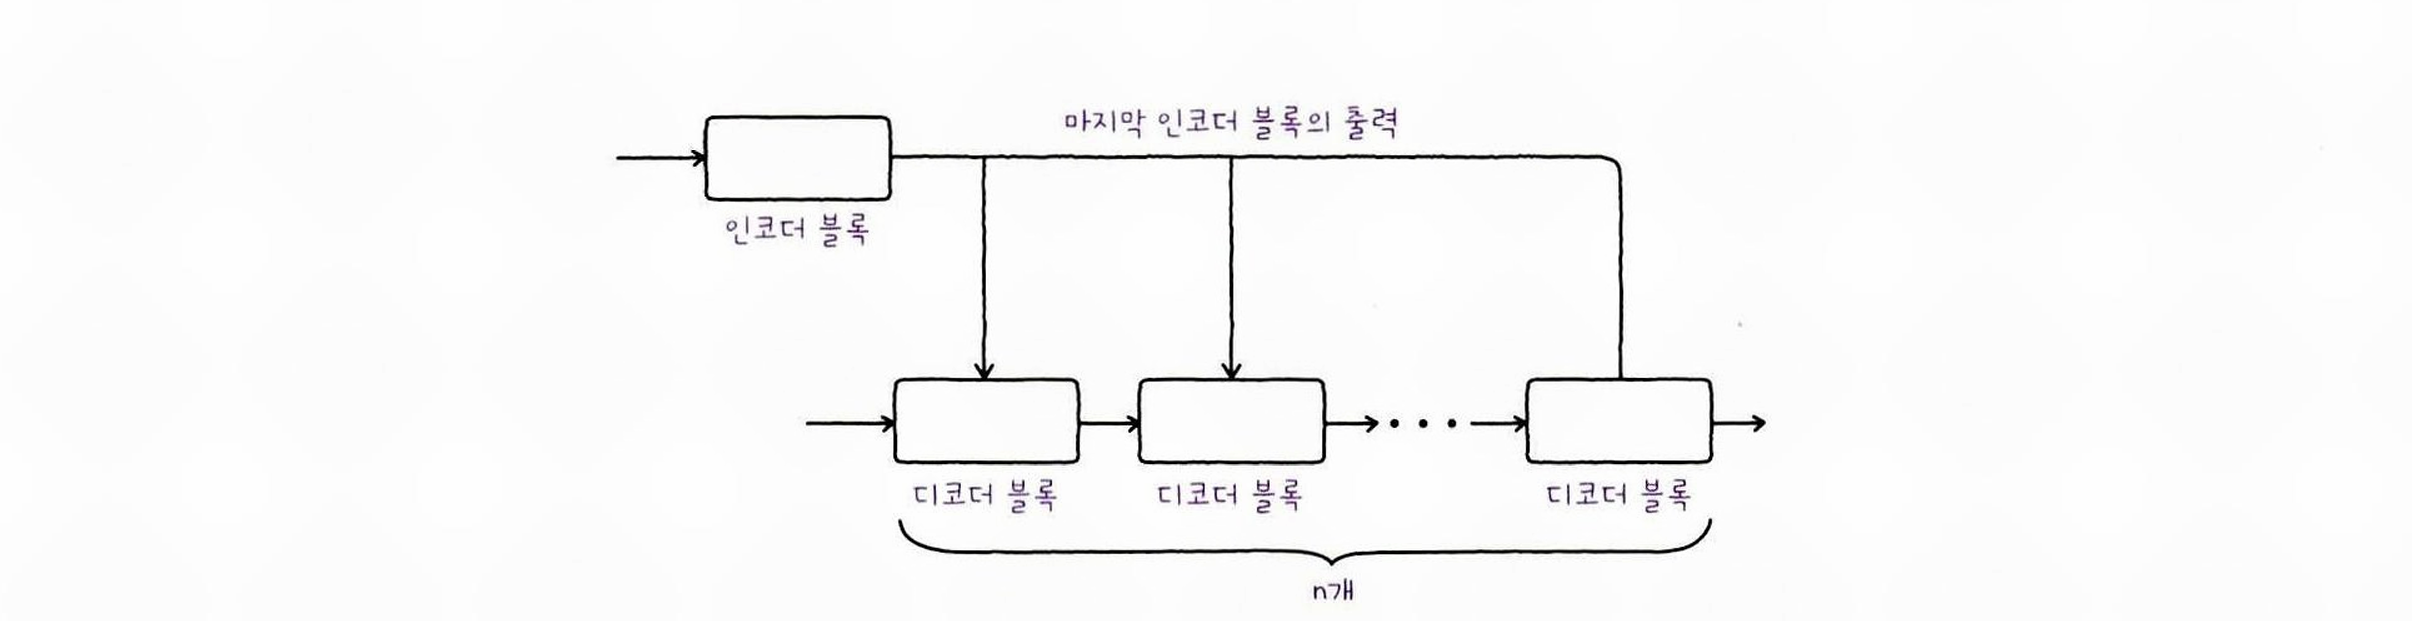

- 디코더 블록이 출력하는 값도 인코더 블록과 마찬가지로 동일한 크기의 은닉 벡터
- 따라서, 여러개 쌓는 것이 가능하고, 해결하고자 하는 작업에 맞는 층을 마지막 디코더 블록 다음에 놓음        
 > 예를 들어 텍스트 분류 작업에서는 마지막 디코더 블록 뒤에 밀집층을 추가해 여러 클래스 중 하나를 예측하도록 설계할 수 있음      

**예시**
1. 인코더의 입력 "I love you" 
2. 문장 전체가 인코더에 전달        
3. 인코더가 각 토큰을 분석하여 각각의 의미를 포함한 은닉 벡터로 만듦
4. 은닉 벡터가 디코더에 전달    
5. 디코더는 자기 회귀 모델의 방식을 따라 한 번에 하나의 토큰만 생성하므로 처음은 "나는" 출력 -> "나는" 입력되고 "너를"출력 -> "나는 너를" 입력되고 "사랑한다" 출력

**그러나 실제로 번역을 수행할 때는**
1. "I love you"의 올바른 번역 "나는 너를 사랑한다"를 디코더에 전달  
2. 각 토큰에서 다음 토큰을 예측하도록 모델을 훈련
3. 디코더는 "나는"에서 "너를"을 예측하고, "나는 너를"을 사용해 "사랑한다"를 예측하도록 훈련

**또 그러나, 다음에 출력할 정답을 미리 알면 올바른 학습 불가**

이를 방지하기 위해 디코더의 첫 번째 멀티 헤드 어텐션 층에서 **마스킹** 처리를 함 
- 즉, 디코더가 한 타임스텝에서 어텐션 점수를 계산할 때 현재 토큰까지만 참고하고, 이후의 토큰은 볼 수 없도록 제한        
따라서, 디코더 블록의 첫번째 멀티 헤드 어텐션 층을 **마스크드 멀티 헤드 어텐션_masked mulit-head attention**층이라고 부름   



트랜스포머는 어텐션, 층 정규화, 잔차 연결, 드롭아웃 같은 기술을 효과적으로 조합하여 새로운 구조를 만들었고, 이를 통해 인코더-디코더 모델에서 순환층을 완전히 제거       
트랜스포머 모델은 대규모 텍스트 데이터셋을 학습하며, 매우 많은 모델 파라미터를 가지고 있다.         
이런 모델을 대규모 언어 모델뉴* language model. LLM이라 부름        


In [1]:
from transformers import pipeline

pipe = pipeline(task='summarization', model='sshleifer/distilbart-cnn-12-6', device=0)


2025-12-03 12:15:46.080206: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-03 12:15:46.155025: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-03 12:15:47.947966: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Device set to use cuda:0
